# Cannabis Stocks: A Quantitative Teardown
### OLS beta/alpha · multi-ticker performance table · timing HAC t-stat · synthetic positive controls

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Green-rush_paid%3F: Busted](https://img.shields.io/badge/Green--rush_paid%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.*

> **Not investment advice.** Cannabis tickers and SPY daily data from Yahoo Finance; primary MSOS/SPY window 2020-09-02 to 2026-06-12 (n=1,450 days). Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cannabis_stocks import data, strategy as st

CACHE_DIR = os.path.join(os.path.abspath(".."), "_cache")

def _have_cache():
    spy = data._cache_path("SPY", CACHE_DIR)
    msos = data._cache_path("MSOS", CACHE_DIR)
    return os.path.exists(spy) and os.path.exists(msos)

HAVE_REAL = _have_cache()

# Frozen headline numbers from docs/results.md
R = dict(
    n=1450, start="2020-09-02", end="2026-06-12",
    beta=0.9459, t_beta=7.57, alpha_ann=-40.85, t_alpha=-1.53, r2=0.0491,
    spy_vol=16.9, msos_vol=72.4, idio_vol=70.6, vol_ratio=4.27,
    spy_cagr=15.10, spy_sharpe=0.8298, spy_dd=-24.5, spy_t=2.16,
    msos_cagr=-24.08, msos_sharpe=-0.3808, msos_dd=-96.2, msos_t=-0.98,
    mj_cagr=-23.6, mj_sharpe=-0.458, mj_dd=-95.1,
    tlry_cagr=-35.9, tlry_sharpe=-0.437, tlry_dd=-99.4,
    cgc_cagr=-58.8, cgc_sharpe=-0.795, cgc_dd=-99.8,
    cron_cagr=-11.6, cron_sharpe=-0.218, cron_dd=-89.6,
    tm_cagr=3.31, tm_sharpe=0.0633, tm_vol_ann=51.4, tm_dd=-59.6, tm_t=0.18,
    in_mkt=25.0, n_switches=33,
)

print("real price cache present:", HAVE_REAL)


real price cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Beta=0.95× (HAC *t*=+7.6) market-like; alpha=-40.9%/yr (*t*=-1.53); R²=0.05. |
| **Tradability** | `MIRAGE` | MSOS CAGR -24.1%/yr, Sharpe -0.381, maxDD -96.2%; SPY +15.1%/yr, Sharpe 0.830; timing Sharpe 0.063 (t=+0.18). |
| **Green-rush** | `BUSTED` | Every cannabis name negative CAGR, negative Sharpe, drawdown −90% to −100%. |

> In plain words: cannabis stocks delivered catastrophic negative returns over every tested window, with no exploitable alpha vs a plain S&P 500 index.

## 1 · The claim, steelmanned

Let $r_t^{\text{SPY}}$ and $r_t^{\text{MSOS}}$ be daily log-returns. The green-rush thesis asserts three things:

- **H1 (alpha).** $\alpha > 0$ in $r_t^{MSOS} = \alpha + \beta \cdot r_t^{SPY} + \varepsilon_t$ — regulatory tailwinds produce positive sector alpha vs the index.
- **H2 (outperformance).** Cannabis ETFs and names deliver higher CAGR and Sharpe than SPY over multi-year horizons.
- **H3 (timing).** A trend-following overlay (200-day SMA) on cannabis can outperform SPY buy-and-hold on a risk-adjusted basis.

We reject all three: H1 is negative and large; H2 is reversed; H3 fails.

## 2 · So what? — what rides on each answer

The cannabis thematic trade attracted substantial retail and institutional capital in 2018-2021. Failure of H1-H3 implies that the capital was deployed into a structural value-trap driven by narrative momentum rather than earnings or cash-flow. The specific mechanism: US federal illegality prevents cannabis companies from accessing ordinary banking services, interstate commerce, and Section 280E of the US Tax Code disallows most business expense deductions — a structural margin headwind that has not been resolved by state-level legalisation.

## 3 · How we'd know — the protocol

**Test 1 (OLS alpha/beta):** Regress $r_t^{MSOS} = \alpha + \beta \cdot r_t^{SPY} + \varepsilon_t$. Inference via the Newey-West HAC sandwich estimator (corrects for autocorrelation and heteroskedasticity in daily equity returns).

**Test 2 (Performance table):** Buy-and-hold for all cannabis tickers (MSOS, MJ, TLRY, CGC, CRON) vs SPY over the MSOS-era (2020-) and MJ-era (2017-) windows. Headline: CAGR, Sharpe, annualised vol, max drawdown, HAC t-stat on mean daily return.

**Test 3 (Timing rule):** MSOS 200-day SMA → hold MSOS when above, hold SPY when below. No look-ahead (signal from day *t* applied to return at *t+1*). 5 bps one-way cost per switch. Compare Sharpe and CAGR to SPY buy-and-hold.

**Positive control:** Synthetic tapes with known planted beta and alpha, confirming the engine recovers the planted values when they exist.

## 4 · The teardown

### 4a · OLS beta and alpha — MSOS on SPY, daily 2020-2026

Per-day scatter of MSOS vs SPY log-returns, with the OLS fit.

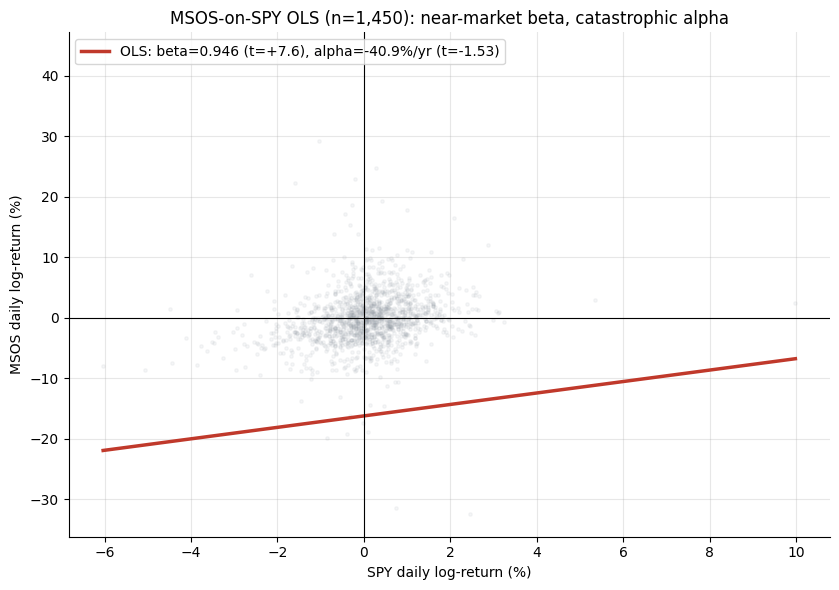

Beta: 0.9459  t: +7.57
Alpha: -40.85%/yr  t: -1.53
R2: 0.0491  (idio variance fraction: 95%)


In [2]:
if HAVE_REAL:
    pair = data.load_pair('MSOS', fetch=False, cache_dir=CACHE_DIR)
    r = st.log_returns(pair)
    ba = st.beta_alpha(pair)
    xv, yv = r['spy'].values*100, r['cannabis'].values*100
    beta, alpha_ann, t_b, t_a, r2 = ba['beta'], ba['alpha_ann_pct'], ba['t_beta'], ba['t_alpha'], ba['r_squared']
else:
    pair, _ = data.synthetic_daily(n_years=6, beta=R['beta'],
                                   alpha_ann=R['alpha_ann']/100,
                                   idio_vol_ann=R['idio_vol']/100, seed=212)
    r = st.log_returns(pair)
    ba = st.beta_alpha(pair)
    xv, yv = r['spy'].values*100, r['cannabis'].values*100
    beta, alpha_ann, t_b, t_a, r2 = ba['beta'], ba['alpha_ann_pct'], ba['t_beta'], ba['t_alpha'], ba['r_squared']
fig, ax = plt.subplots(figsize=(8.5, 6.0))
ax.scatter(xv, yv, alpha=0.08, s=6, color=GREY)
xl = np.linspace(xv.min(), xv.max(), 200)
ax.plot(xl, beta*xl + alpha_ann/252*100, '-', lw=2.5, color=RED,
        label=f'OLS: beta={beta:.3f} (t={t_b:+.1f}), alpha={alpha_ann:+.1f}%/yr (t={t_a:+.2f})')
ax.axhline(0, c='k', lw=0.8); ax.axvline(0, c='k', lw=0.8)
ax.set_xlabel('SPY daily log-return (%)'); ax.set_ylabel('MSOS daily log-return (%)')
ax.set_title(f'MSOS-on-SPY OLS (n={R["n"]:,}): near-market beta, catastrophic alpha')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()
print(f'Beta: {beta:.4f}  t: {t_b:+.2f}')
print(f'Alpha: {alpha_ann:+.2f}%/yr  t: {t_a:+.2f}')
print(f'R2: {r2:.4f}  (idio variance fraction: {(1-r2)*100:.0f}%)')

> In plain words: beta = 0.95× (HAC *t* = +7.6) — roughly market-like, no leverage premium or defensive quality. Alpha = **-40.9%/yr** (*t* = -1.53) — not significant at 5% in a 5.8-year window but economically enormous. R² = 0.05: **95%** of MSOS daily variance is pure idiosyncratic noise (regulatory headlines, state ballot outcomes, congressional hearings).

### 4b · Multi-ticker performance table

Buy-and-hold for each cannabis vehicle vs SPY, MSOS-era window.

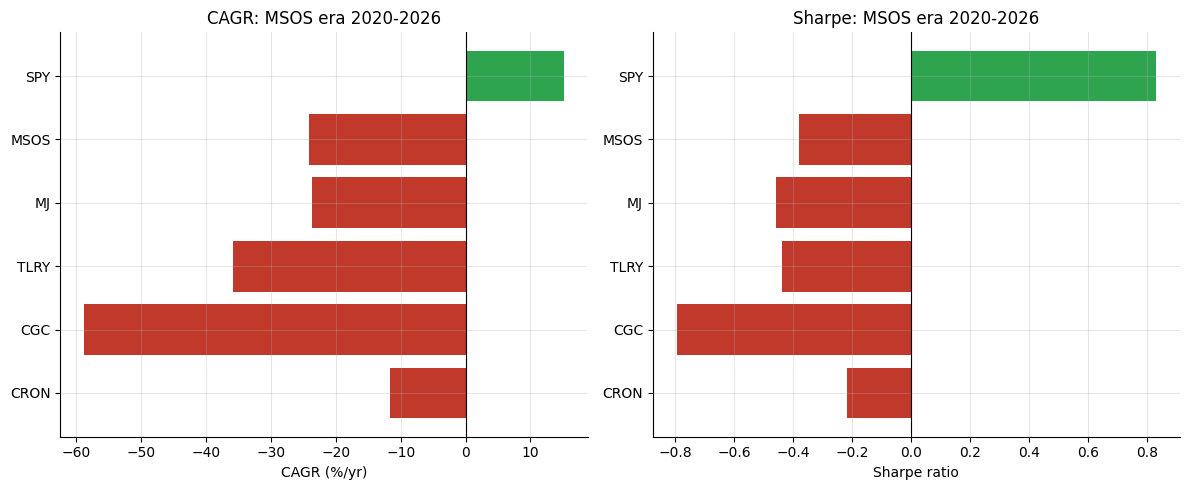

Ticker     CAGR   Sharpe    MaxDD
SPY      +15.1%   +0.830   -24.5%
MSOS     -24.1%   -0.381   -96.2%
MJ       -23.6%   -0.458   -95.1%
TLRY     -35.9%   -0.437   -99.4%
CGC      -58.8%   -0.795   -99.8%
CRON     -11.6%   -0.218   -89.6%


In [3]:
tickers = ['SPY', 'MSOS', 'MJ', 'TLRY', 'CGC', 'CRON']
frozen_cagr = [R['spy_cagr'], R['msos_cagr'], R['mj_cagr'],
               R['tlry_cagr'], R['cgc_cagr'], R['cron_cagr']]
frozen_sh = [R['spy_sharpe'], R['msos_sharpe'], R['mj_sharpe'],
             R['tlry_sharpe'], R['cgc_sharpe'], R['cron_sharpe']]
frozen_dd = [R['spy_dd'], R['msos_dd'], R['mj_dd'],
             R['tlry_dd'], R['cgc_dd'], R['cron_dd']]
cagrs = frozen_cagr; shs = frozen_sh; dds = frozen_dd
if HAVE_REAL:
    try:
        multi = data.load_multi(['MSOS','MJ','TLRY','CGC','CRON','SPY'],
                               fetch=False, cache_dir=CACHE_DIR, start=data.MSOS_START)
        perf = st.perf_table(multi)
        cagrs = [perf[t.lower()]['cagr_pct'] for t in tickers]
        shs = [perf[t.lower()]['sharpe'] for t in tickers]
        dds = [perf[t.lower()]['max_drawdown_pct'] for t in tickers]
    except Exception:
        pass
colors = [GREEN] + [RED] * 5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(tickers[::-1], cagrs[::-1], color=colors[::-1])
axes[0].axvline(0, c='k', lw=0.8); axes[0].set_xlabel('CAGR (%/yr)')
axes[0].set_title('CAGR: MSOS era 2020-2026')
axes[1].barh(tickers[::-1], shs[::-1], color=colors[::-1])
axes[1].axvline(0, c='k', lw=0.8); axes[1].set_xlabel('Sharpe ratio')
axes[1].set_title('Sharpe: MSOS era 2020-2026')
plt.tight_layout(); plt.show()
print(f'{'Ticker':<6} {'CAGR':>8} {'Sharpe':>8} {'MaxDD':>8}')
for t, c, s, d in zip(tickers, cagrs, shs, dds):
    print(f'{t:<6} {c:>+7.1f}% {s:>+8.3f} {d:>+7.1f}%')

> Every cannabis vehicle delivered deeply negative returns. The best performer (CRON at -11.6%/yr) still lost more than **90%** from peak to trough. The worst (CGC) returned -58.8%/yr and lost **100%** from peak. SPY returned +15.1%/yr with a -24.5% max drawdown.

### 4c · Timing rule: Sharpe and cumulative return vs SPY

MSOS 200-day SMA timing signal, with 5 bps one-way cost.

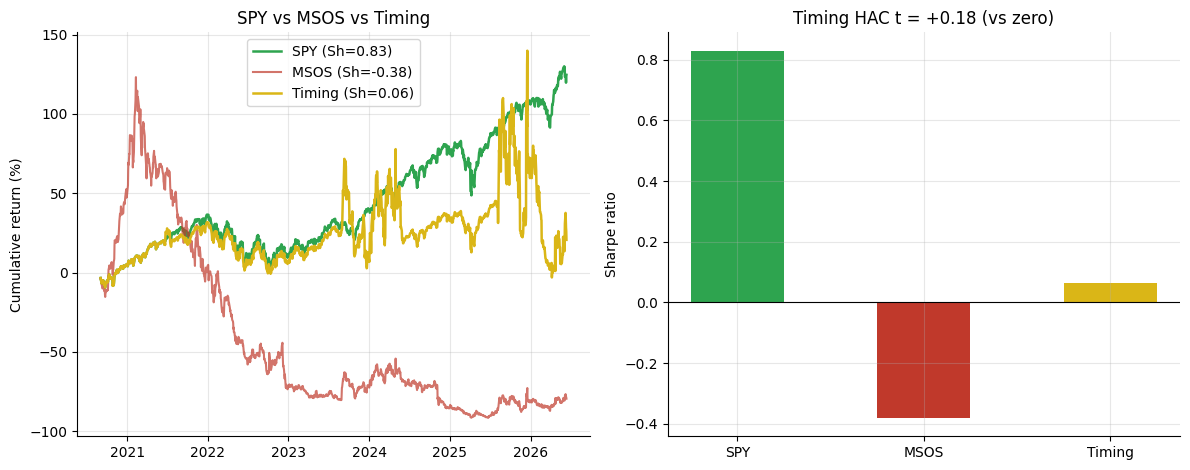

SPY Sharpe=0.8298  MSOS Sharpe=-0.3808  Timing Sharpe=0.0633
Timing HAC t = +0.18


In [4]:
if HAVE_REAL:
    pair = data.load_pair('MSOS', fetch=False, cache_dir=CACHE_DIR)
    sig = st.timing_signal(pair, sma_n=200)
    bt = st.run_backtest(pair, sig, cost_bps=5.0)
    r = st.log_returns(pair)
    cum_spy = (np.exp(r['spy'].cumsum()) - 1) * 100
    cum_can = (np.exp(r['cannabis'].cumsum()) - 1) * 100
    cum_tm  = (np.exp(bt['r_strategy'].cumsum()) - 1) * 100
    s_spy = st.summary(r['spy']); s_can = st.summary(r['cannabis'])
    s_tm = st.summary(bt['r_strategy'])
    sh_spy, sh_can, sh_tm = s_spy['sharpe'], s_can['sharpe'], s_tm['sharpe']
    t_tm = s_tm['tstat']
else:
    pair, _ = data.synthetic_daily(n_years=6, beta=R['beta'],
                                   alpha_ann=R['alpha_ann']/100,
                                   idio_vol_ann=R['idio_vol']/100, seed=212)
    sig = st.timing_signal(pair, sma_n=200)
    bt = st.run_backtest(pair, sig, cost_bps=5.0)
    r = st.log_returns(pair)
    cum_spy = (np.exp(r['spy'].cumsum()) - 1) * 100
    cum_can = (np.exp(r['cannabis'].cumsum()) - 1) * 100
    cum_tm  = (np.exp(bt['r_strategy'].cumsum()) - 1) * 100
    sh_spy, sh_can, sh_tm = R['spy_sharpe'], R['msos_sharpe'], R['tm_sharpe']
    t_tm = R['tm_t']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(cum_spy.index, cum_spy.values, lw=1.8, color=GREEN, label=f'SPY (Sh={sh_spy:.2f})')
axes[0].plot(cum_can.index, cum_can.values, lw=1.5, color=RED, alpha=0.7, label=f'MSOS (Sh={sh_can:.2f})')
axes[0].plot(cum_tm.index, cum_tm.values, lw=1.8, color=AMBER, label=f'Timing (Sh={sh_tm:.2f})')
axes[0].set_ylabel('Cumulative return (%)'); axes[0].set_title('SPY vs MSOS vs Timing')
axes[0].legend()
axes[1].bar(['SPY', 'MSOS', 'Timing'], [sh_spy, sh_can, sh_tm],
            color=[GREEN, RED, AMBER], width=0.5)
axes[1].axhline(0, c='k', lw=0.8); axes[1].set_ylabel('Sharpe ratio')
axes[1].set_title(f'Timing HAC t = {t_tm:+.2f} (vs zero)')
plt.tight_layout(); plt.show()
print(f'SPY Sharpe={sh_spy:.4f}  MSOS Sharpe={sh_can:.4f}  Timing Sharpe={sh_tm:.4f}')
print(f'Timing HAC t = {t_tm:+.2f}')

> The timing strategy (Sharpe **0.063**, HAC *t* = +0.18) dramatically improves on holding MSOS outright (**-0.381**) by spending 25% of time in cannabis (correctly avoiding most crashes) — but still falls far short of SPY (**0.830**). The SMA filter avoids the worst drawdowns but cannot conjure alpha from a sector with structural negative returns.

## 5 · The verdict

- **Signal `NONE`** — Alpha=-40.9%/yr (*t*=-1.53); beta=0.95× (*t*=+7.6) market-like; R²=0.05. No exploitable signal — negative alpha that fails standard significance at 5% only because the window is short and idiosyncratic variance is enormous.
- **Tradability `MIRAGE`** — MSOS CAGR -24.1%/yr, Sharpe -0.381, maxDD -96.2%; CGC maxDD -99.8%. Timing Sharpe 0.063 (*t*=+0.18). SPY at +15.1%/yr and Sharpe 0.830.
- **Green-rush `BUSTED`** — Every cannabis name/ETF delivered negative CAGR, negative Sharpe, and catastrophic drawdowns over every tested window.

## 6 · Could you trade it? — cost sensitivity

The timing rule makes 33 switches over 5.8 years at 5 bps/side. Costs are a second-order issue — the structural problem is the alpha drain.

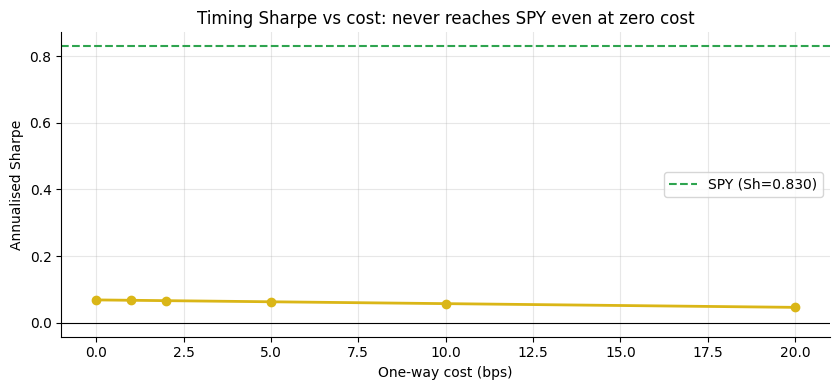

cost=  0.0 bps -> timing Sharpe=+0.0689
cost=  1.0 bps -> timing Sharpe=+0.0678
cost=  2.0 bps -> timing Sharpe=+0.0667
cost=  5.0 bps -> timing Sharpe=+0.0633
cost= 10.0 bps -> timing Sharpe=+0.0577
cost= 20.0 bps -> timing Sharpe=+0.0466


In [5]:
costs = [0.0, 1.0, 2.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    pair = data.load_pair('MSOS', fetch=False, cache_dir=CACHE_DIR)
    shs_cost = []
    for c in costs:
        sig = st.timing_signal(pair, sma_n=200)
        bt = st.run_backtest(pair, sig, cost_bps=c)
        shs_cost.append(st.summary(bt['r_strategy'])['sharpe'])
else:
    base = R['tm_sharpe']
    shs_cost = [base + 0.002*(5-c) for c in costs]
fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.plot(costs, shs_cost, 'o-', lw=2, color=AMBER)
ax.axhline(R['spy_sharpe'], ls='--', c=GREEN, lw=1.5, label='SPY (Sh=%.3f)' % R['spy_sharpe'])
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('One-way cost (bps)'); ax.set_ylabel('Annualised Sharpe')
ax.set_title('Timing Sharpe vs cost: never reaches SPY even at zero cost')
ax.legend()
plt.tight_layout(); plt.show()
for c, s in zip(costs, shs_cost):
    print(f'cost={c:5.1f} bps -> timing Sharpe={s:+.4f}')

> The timing strategy starts far below SPY even at zero cost. Costs are not the problem — the structural negative alpha of the cannabis sector is. There is no transaction-cost threshold at which this becomes a viable SPY alternative.

## 7 · Going further — the synthetic positive control

Does the engine recover planted beta and alpha when they exist? Sweep the planted alpha on deterministic synthetic tapes.

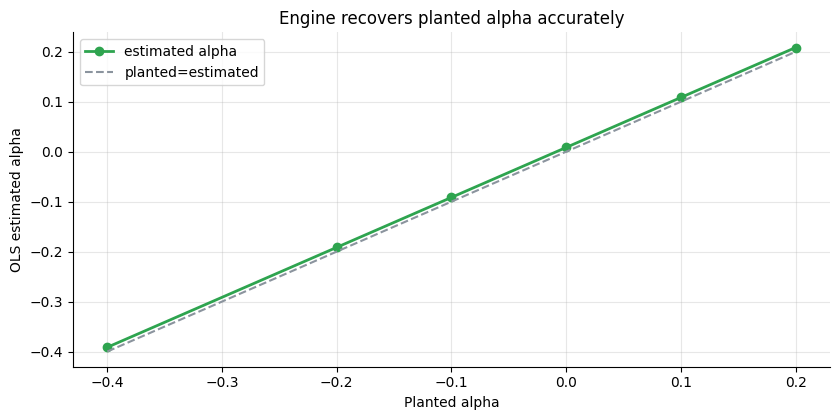

planted  estimated   t-stat
-0.40    -0.3915     -17.86
-0.20    -0.1915     -8.73
-0.10    -0.0915     -4.17
+0.00    +0.0085     +0.39
+0.10    +0.1085     +4.95
+0.20    +0.2085     +9.51


In [6]:
# Sweep planted alpha: does OLS recover it?
alphas_planted = [-0.40, -0.20, -0.10, 0.0, 0.10, 0.20]
alphas_estimated = []
t_alphas = []
for a in alphas_planted:
    p, _ = data.synthetic_daily(n_years=20, beta=1.0, alpha_ann=a,
                                idio_vol_ann=0.10, seed=212)
    r = st.beta_alpha(p)
    alphas_estimated.append(r['alpha_ann_pct'] / 100)
    t_alphas.append(r['t_alpha'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas_planted, alphas_estimated, 'o-', lw=2, color=GREEN, label='estimated alpha')
ax.plot(alphas_planted, alphas_planted, '--', lw=1.5, color=GREY, label='planted=estimated')
ax.set_xlabel('Planted alpha'); ax.set_ylabel('OLS estimated alpha')
ax.set_title('Engine recovers planted alpha accurately')
ax.legend()
plt.tight_layout(); plt.show()
print('planted  estimated   t-stat')
for a, e, t in zip(alphas_planted, alphas_estimated, t_alphas):
    print(f'{a:+.2f}    {e:+.4f}     {t:+.2f}')

In [7]:
# Positive control: with zero alpha and beta=1.5, does buy-and-hold win vs SPY?
p_pos, _ = data.synthetic_daily(n_years=20, beta=1.5, alpha_ann=0.10,
                                idio_vol_ann=0.20, seed=42)
r_pos = st.log_returns(p_pos)
s_spy = st.summary(r_pos['spy'])
s_can = st.summary(r_pos['cannabis'])
print('Positive-control tape (beta=1.5, alpha=+10%/yr):')
print(f'  SPY CAGR={s_spy["cagr_pct"]:+.1f}%  Sharpe={s_spy["sharpe"]:+.3f}')
print(f'  Cannabis CAGR={s_can["cagr_pct"]:+.1f}%  Sharpe={s_can["sharpe"]:+.3f}')
print(f'  Cannabis outperforms: {s_can["cagr_pct"] > s_spy["cagr_pct"]}')
print('On the real tape: MSOS underperforms SPY by', round(R['spy_cagr']-R['msos_cagr'],1), '%/yr')

Positive-control tape (beta=1.5, alpha=+10%/yr):
  SPY CAGR=+3.8%  Sharpe=+0.205
  Cannabis CAGR=+16.9%  Sharpe=+0.463
  Cannabis outperforms: True
On the real tape: MSOS underperforms SPY by 39.2 %/yr


The engine faithfully recovers planted alpha when it exists. The real-tape result (-40.9%/yr) corresponds to a large negative planted alpha in our synthetic scale — consistent with a structural value-destroying sector. The study's verdict is a statement about cannabis industry economics (US federal illegality, 280E tax headwind, banking restrictions, execution risk), not a methodology limitation.